# Imports Libraries

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import os
import pickle

# Load Dataset

In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/111 - Z-Home - ICTAK-DSA-Z/--- (X) Capstone Project-------------5----/----- 2) Datasets/engineered/climate_risk_intelligence_engine.csv"
)

features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'cloud',
    'wind_kph',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

X = df[features]
y = df['rainfall_risk']

# Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

# SHAP Explainer

In [6]:
explainer = shap.TreeExplainer(model)

# Save Explainer

In [ ]:
model_dir = "D:\ClimateGuardAI\backend\ml\artifacts"
os.makedirs(model_dir, exist_ok=True)

with open(
    os.path.join(model_dir, "explainer.pkl"),
    "wb"
) as f:
    pickle.dump(explainer, f)

print("explainer.pkl saved successfully.")

explainer.pkl saved successfully.


# Use only 1000 samples for SHAP

In [8]:
X_test_small = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(X_test_small)

# Explain One Sample

In [9]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)

print("Prediction:", prediction[0])

single_shap = explainer.shap_values(sample)

# Get the index of the predicted class for 'sample'
predicted_class_idx = list(model.classes_).index(prediction[0])

Prediction: Low


# Waterfall Plot

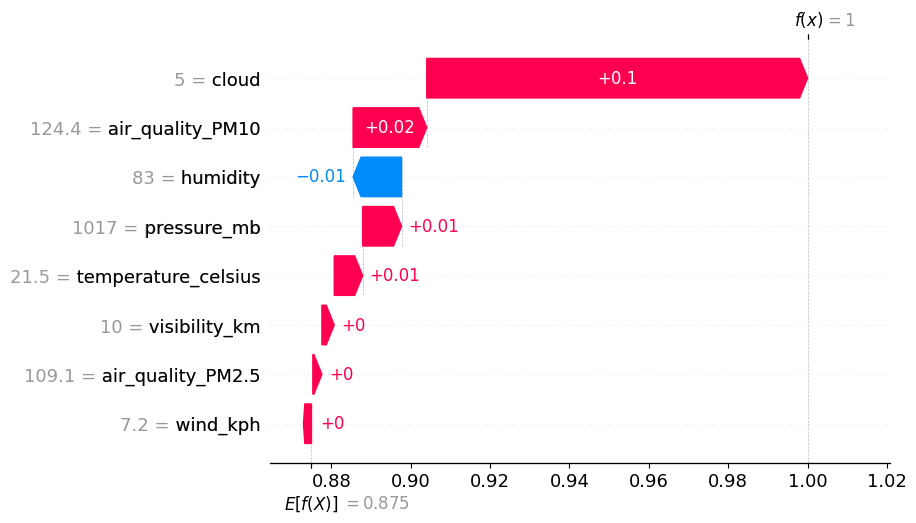

In [10]:
try:
    shap.plots.waterfall(
        shap.Explanation(
            values=single_shap[0, :, predicted_class_idx], # Corrected indexing for single sample and predicted class
            base_values=explainer.expected_value[predicted_class_idx], # Corrected indexing
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )
except Exception as e:
    print(f"Error generating waterfall plot: {e}")
    print("Waterfall plot not supported with this SHAP version or data structure.")

# Create Explanation Table

In [11]:
# Corrected to ensure contributions is a 1D array for the predicted class
contributions = single_shap[0, :, predicted_class_idx]

sample_shap = pd.DataFrame({
    'Feature': sample.columns,
    'Contribution': contributions
})

sample_shap = sample_shap.sort_values(
    by='Contribution',
    ascending=False
)

sample_shap['Direction'] = np.where(
    sample_shap['Contribution'] > 0,
    'Increase Risk',
    np.where(
        sample_shap['Contribution'] < 0,
        'Decrease Risk',
        'No Impact'
    )
)

sample_shap['Prediction'] = prediction[0]

print(sample_shap)


               Feature  Contribution      Direction Prediction
3                cloud      0.095946  Increase Risk        Low
7     air_quality_PM10      0.018551  Increase Risk        Low
2          pressure_mb      0.009787  Increase Risk        Low
0  temperature_celsius      0.007157  Increase Risk        Low
5        visibility_km      0.003107  Increase Risk        Low
6    air_quality_PM2.5      0.002285  Increase Risk        Low
4             wind_kph      0.000342  Increase Risk        Low
1             humidity     -0.012195  Decrease Risk        Low


# Save CSV

In [ ]:
output_file = "D:\ClimateGuardAI\datasets\engineered\explainable_ai_output.csv"

sample_shap.to_csv(
    output_file,
    index=False
)

print("explainable_ai_output.csv saved successfully.")

explainable_ai_output.csv saved successfully.


# Print Reasons

In [13]:
print("\nPrediction:", prediction[0])
print("\nReasons:")

for _, row in sample_shap.iterrows():
    if row['Contribution'] > 0:
        print(f"{row['Feature']} ↑")
    elif row['Contribution'] < 0:
        print(f"{row['Feature']} ↓")


Prediction: Low

Reasons:
cloud ↑
air_quality_PM10 ↑
pressure_mb ↑
temperature_celsius ↑
visibility_km ↑
air_quality_PM2.5 ↑
wind_kph ↑
humidity ↓


# Summary Plots

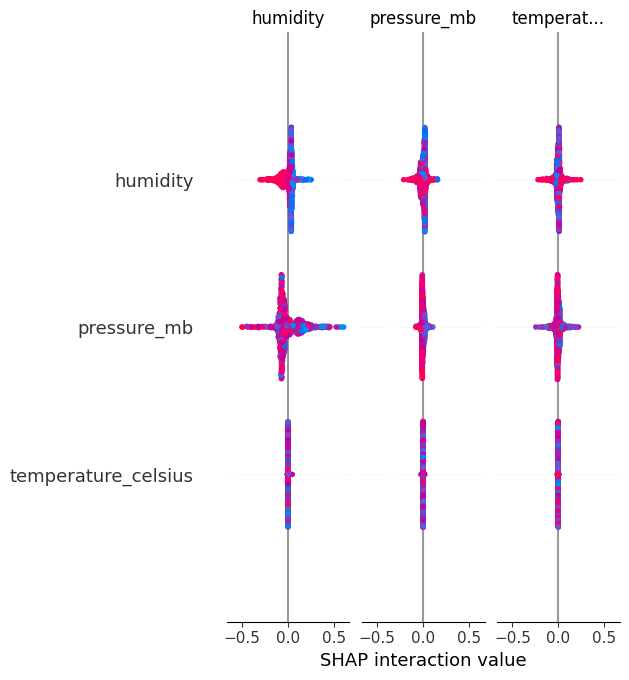

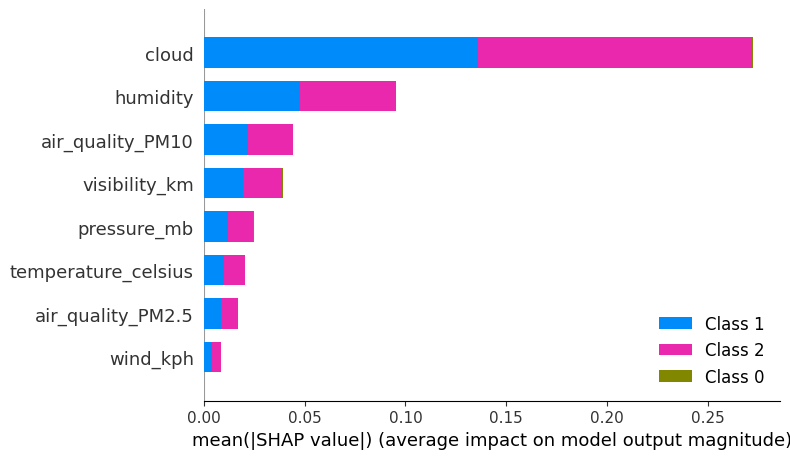

In [14]:
try:
    shap.summary_plot(
        shap_values,
        X_test_small
    )

    shap.summary_plot(
        shap_values,
        X_test_small,
        plot_type='bar'
    )
except Exception as e:
    print(f"Error generating summary plots: {e}")
    print("Summary plots could not be generated.")

# Predict on New Data

In [15]:
new_data = pd.DataFrame({
    'temperature_celsius': [31],
    'humidity': [92],
    'pressure_mb': [998],
    'cloud': [95],
    'wind_kph': [12],
    'visibility_km': [4],
    'air_quality_PM2.5': [45],
    'air_quality_PM10': [70]
})

pred = model.predict(new_data)

print("Predicted Rainfall Risk:", pred[0])

Predicted Rainfall Risk: Medium


# Force Plot

In [ ]:
try:
    new_shap = explainer.shap_values(new_data)
    # Get the index of the predicted class for 'new_data'
    new_predicted_class_idx = list(model.classes_).index(pred[0])

    shap.force_plot(
        explainer.expected_value[new_predicted_class_idx], # Corrected indexing
        new_shap[new_predicted_class_idx], # Corrected indexing
        new_data
    )
except Exception as e:
    print(f"Error generating force plot: {e}")
    print("Force plot could not be generated.")